## 🤖 Auswahl des Machine-Learning-Algorithmus

Zur Lösung der Problemstellung wurde ein **überwachtes Klassifikationsmodell** eingesetzt,  
da das Ziel darin besteht, anhand **vor dem Rennen bekannter Merkmale** vorherzusagen,  
ob ein Fahrer eine **Top-10-Platzierung** erreicht oder nicht.

---

### 🧠 Primärer Algorithmus: **Logistische Regression**

#### 📝 Begründung der Modellwahl:
- ✅ Etabliertes **Baseline-Modell** für binäre Klassifikationsprobleme  
- 📊 Besonders geeignet für **strukturierte tabellarische Daten**  
- 🔍 **Gut interpretierbar** – Einfluss einzelner Merkmale über Modellkoeffizienten nachvollziehbar  
- ⚙️ **Geringe Rechenkomplexität** → stabile & reproduzierbare Ergebnisse

---

### 🚀 Zweites Modell: **LightGBM-Klassifikator**

Wir haben erst einen Random Forest probiert und sind dann zu **LightGBM** gewechselt. 
Einfach gesagt: LightGBM baut viele Entscheidungsbäume hintereinander auf, lernt aus den Fehlern der vorherigen Bäume und wird so Schritt für Schritt besser. 
Dadurch ist es oft genauer und schneller als ein einzelner Random Forest. LightGBM kommt gut mit vielen Spalten (z. B. vielen One-Hot-Dummies) zurecht, skaliert bei größeren Datensätzen effizient und kann feinere Muster erkennen

https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html#lightgbm.LGBMClassifier

---

### ✅ Validierung

- **Stratifizierte CV** für robuste Durchschnittsmetriken.  
- **TimeSeriesSplit** für zeitlich korrekte Validierung (keine Durchmischung in die Zukunft), um Generalisierung auf zukünftige Rennen realistisch abzuschätzen.


In [19]:
import pandas as pd
import numpy as np


In [20]:
feature_df = pd.read_csv("../data/processed/driver_race_features.csv")
print(feature_df.shape)
feature_df.head()


(25121, 10)


,season,round,raceId,race_date,grid,driver_experience,driver_recent_form,constructor_strength,grid_bucket,target_top10
0,1968,8,674,1968-08-04,16,83,9.6,11.817451,mid_11_20,0
1,1968,11,677,1968-10-06,5,36,3.6,13.000000,top10_4_10,1
2,1971,1,632,1971-03-06,7,60,9.0,10.500000,top10_4_10,1
3,1971,1,632,1971-03-06,11,7,10.4,9.000000,mid_11_20,0
4,1971,1,632,1971-03-06,23,101,12.6,12.500000,back_21+,0


## 🗺️ Holdout: letztes Rennen ausklammern

Wir halten das zeitlich letzte Rennen im Datensatz als **Holdout** zurück, um zu sehen, wie gut das Modell auf ein tatsächlich unbekanntes Event **generalisiert**. Ein Holdout bleibt **komplett außerhalb des Trainings**: Wir filtern das **jüngste Rennen (per Datum)**, sichern diese Zeilen separat und trainieren auf dem Rest. So vermeiden wir, dass das Modell Ergebnisse kennt, die es eigentlich vorhersagen soll, und können später die Prognosen mit dem realen Ausgang vergleichen.

Die Daten sind **chronologisch sortiert**, daher ist es sinnvoll, ein Rennen aus der **Zukunftsperspektive** des Modells zu testen. Ein **vergangenes Rennen** als Holdout wäre weniger aussagekräftig, weil das Modell bei **zeitlicher Durchmischung** indirekt Information darüber lernen könnte (**Data Leakage**) und die Generalisierung **überschätzt** würde.


Wir kommen später auf **Marina Circuit** zurück, um die Vorhersagen gegen das **reale Ergebnis** zu spiegeln.

> 🧠 Ein **Holdout** ist ein bewusst zurückgehaltener Datensatz, der **nicht zum Trainieren** verwendet wird. Man trainiert das Modell auf dem übrigen Teil der Daten und prüft es erst danach auf dem Holdout. So sieht man, wie gut das Modell auf **wirklich unbekannte Fälle** generalisiert und ob es **überfittet**. Oft ist der Holdout ein **bestimmter Zeitraum**, eine **Kundengruppe** oder ein **zufällig abgetrennter Teil** der Daten.




In [21]:
# Hold out the latest race by date (remove from training)
df = feature_df.copy()
if "race_date_parsed" not in df.columns:
    df["race_date_parsed"] = pd.to_datetime(df.get("race_date"), errors="coerce")
if df["race_date_parsed"].isna().all():
    raise ValueError("No valid race_date values to identify the latest race.")

latest = df.sort_values("race_date_parsed").iloc[-1]
HOLDOUT_SEASON = int(latest["season"])
HOLDOUT_ROUND = int(latest["round"])
HOLDOUT_RACEID = latest.get("raceId")
HOLDOUT_CIRCUIT_NAME = latest.get("circuit_name", "")

mask_terms = [
    df["season"] == HOLDOUT_SEASON,
    df["round"] == HOLDOUT_ROUND,
]
if HOLDOUT_RACEID is not None and "raceId" in df.columns:
    mask_terms.append(df["raceId"] == HOLDOUT_RACEID)

mask_holdout = mask_terms[0]
for m in mask_terms[1:]:
    mask_holdout &= m

holdout_df = df[mask_holdout].copy()
feature_df_train = df[~mask_holdout].copy()

print("Holdout race:", HOLDOUT_SEASON, HOLDOUT_ROUND, HOLDOUT_RACEID, HOLDOUT_CIRCUIT_NAME)
print("Holdout rows:", holdout_df.shape)
print("Training rows:", feature_df_train.shape)

holdout_path = "../data/processed/holdout_latest_race.csv"
holdout_df.to_csv(holdout_path, index=False)
print("Saved holdout to", holdout_path)



Holdout race: 2024 24 1144 
Holdout rows: (20, 11)
Training rows: (25101, 11)
Saved holdout to ../data/processed/holdout_latest_race.csv


In [22]:
y = feature_df_train["target_top10"]

X = feature_df_train.drop(columns=[
    "target_top10",
    "race_date",
    "raceId",
    "grid",
    "driver_name",
    "constructor_name",
    "circuit_name",
    # remove leakage-like identifiers / context
    "driverId",
    "constructorId",
    "circuitId",
    "era",
    # optional (time shortcuts)
    "season",
    "round"
], errors="ignore")

print(X.shape, y.shape)


(25101, 5) (25101,)


## 🧪 Vorbereitung der Daten für das Training

Für das Modelltraining wurden **ausschließlich Pre-Race-Features** verwendet – also Merkmale,  
die **vor Rennbeginn bekannt** sind, um **Datenleckagen (Data Leakage)** zu vermeiden.

---

### 🧾 Die Feature-Matrix enthielt unter anderem:

- 🏁 **Startposition (Grid)** und **Grid-Kategorien**  
- 🧑‍✈️ **Fahrer-Erfahrung** (Anzahl vorheriger Rennen)  
- 📈 **Aktuelle Fahrerform** (rollierender Mittelwert vorheriger Ergebnisse)  
- 🛠️ **Teamstärke** (historische durchschnittliche Platzierungen)  
- 🗺️ **Strecke** und **Epoche** (kategorisch)

---

### ⚙️ Vorverarbeitungsschritte:

- 📊 **Numerische Merkmale** wurden **standardisiert**,  
  um unterschiedliche Wertebereiche auszugleichen  
- 🔤 **Kategorische Merkmale** wurden mittels **One-Hot-Encoding**  
  in numerische Repräsentationen überführt  
- 🧱 Alle Schritte wurden in einer **Pipeline** zusammengefasst,  
  um eine **konsistente und korrekte Anwendung** während jeder Trainingsiteration zu gewährleisten



In [23]:
cat_cols = ["grid_bucket"]  # only categorical feature that still exists
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("Encoded:", X_encoded.shape)


Encoded: (25101, 7)


In [24]:
print(y.value_counts())
print(y.value_counts(normalize=True))


target_top10
0    13804
1    11297
Name: count, dtype: int64
target_top10
0    0.549938
1    0.450062
Name: proportion, dtype: float64


In [25]:
X_encoded.dtypes.value_counts()


bool              3
float64           2
int64             1
datetime64[ns]    1
Name: count, dtype: int64

In [26]:
dt_cols = X_encoded.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns
print("Datetime cols in X_encoded:", list(dt_cols))
X_encoded = X_encoded.drop(columns=dt_cols)

Datetime cols in X_encoded: ['race_date_parsed']


### ⚙️ Validierung

Wir nutzen 2 Validierungen, weil sie unterschiedliche Fragen beantworten:

### Stratifizierte Kreuzvalidierung (Vergleich, beide Modelle)

Wir prüfen LogReg und LightGBM zuerst mit stratifizierter CV, um einen allgemeinen Eindruck über alle Daten zu bekommen und die Klassenbalance in jedem Fold zu wahren. Diese Werte dienen dem Modellvergleich, sind aber zeitlich gemischt.

### Zeitreihen-Validierung (entscheidend, beide Modelle)

Für die eigentliche Modellauswahl nutzen wir `TimeSeriesSplit`: train nur auf früheren Rennen, Test auf späteren Rennen. So vermeiden wir zeitliche Lecks und erhalten eine realistischere Aussage zur Generalisierung auf zukünftige Events. Diese Scores sind maßgeblich.

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html  

Beides zusammen zeigt die **allgemeine** Performance (stratifiziert) und die realistisch **zeitbezogene** Performance (Zeit-Split).

In [27]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

num_cols = ["driver_experience", "driver_recent_form", "constructor_strength", "round", "season"]
num_cols = [c for c in num_cols if c in X_encoded.columns]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
    ],
    remainder="passthrough"
)

logreg = LogisticRegression(max_iter=5000, solver="lbfgs")

pipeline_lr = Pipeline([
    ("preprocess", preprocess),
    ("model", logreg)
])

cv = TimeSeriesSplit(n_splits=5)

scoring = ["accuracy", "precision", "recall", "f1"]

scores_lr = cross_validate(
    pipeline_lr,
    X_encoded,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision"   # PR-AUC
    ],
    n_jobs=-1,
    error_score="raise"
)

for m in scoring:
    vals = scores_lr[f"test_{m}"]
    print(f"LogReg {m}: mean={vals.mean():.3f}, std={vals.std():.3f}")


LogReg accuracy: mean=0.691, std=0.023
LogReg precision: mean=0.641, std=0.058
LogReg recall: mean=0.525, std=0.189
LogReg f1: mean=0.567, std=0.138


In [28]:
import lightgbm as lgb
from sklearn.model_selection import cross_validate, TimeSeriesSplit

# LightGBM classifier
lgbm = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    class_weight='balanced'
)

# Stratified CV (uses existing cv)
scores_lgbm = cross_validate(
    lgbm,
    X_encoded,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision"
    ],
    n_jobs=-1,
    error_score="raise",
)

for m in scoring:
    vals = scores_lgbm[f"test_{m}"]
    print(f"LGBM (Stratified) {m}: mean={vals.mean():.3f}, std={vals.std():.3f}")

# Time-aware CV
tscv = TimeSeriesSplit(n_splits=5)
scores_lgbm_ts = cross_validate(
    lgbm,
    X_encoded,
    y,
    cv=tscv,
    scoring=scoring,
    n_jobs=-1,
    error_score="raise",
)

for m in scoring:
    vals = scores_lgbm_ts[f"test_{m}"]
    print(f"LGBM (TimeSeriesSplit) {m}: mean={vals.mean():.3f}, std={vals.std():.3f}")


[LightGBM] [Info] Number of positive: 8108, number of negative: 8627
[LightGBM] [Info] Number of positive: 6440, number of negative: 6112
[LightGBM] [Info] Number of positive: 9499, number of negative: 11419
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000374 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000433 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000433 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 647[LightGBM] [Info] Total Bins 615

[LightGBM] [Info] Total Bins 685
[LightGBM] [Inf

In [29]:
comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy_mean": scores_lr["test_accuracy"].mean(),
        "Precision_mean": scores_lr["test_precision"].mean(),
        "Recall_mean": scores_lr["test_recall"].mean(),
        "F1_mean": scores_lr["test_f1"].mean(),
        "ROC_AUC_mean": scores_lr.get("test_roc_auc", pd.Series()).mean(),
        "Accuracy_std": scores_lr["test_accuracy"].std(),
        "Precision_std": scores_lr["test_precision"].std(),
        "Recall_std": scores_lr["test_recall"].std(),
        "F1_std": scores_lr["test_f1"].std(),
        "ROC_AUC_std": scores_lr.get("test_roc_auc", pd.Series()).std()
    },
    {
        "Model": "LightGBM",
        "Accuracy_mean": scores_lgbm["test_accuracy"].mean(),
        "Precision_mean": scores_lgbm["test_precision"].mean(),
        "Recall_mean": scores_lgbm["test_recall"].mean(),
        "F1_mean": scores_lgbm["test_f1"].mean(),
        "ROC_AUC_mean": scores_lgbm.get("test_roc_auc", pd.Series()).mean(),
        "Accuracy_std": scores_lgbm["test_accuracy"].std(),
        "Precision_std": scores_lgbm["test_precision"].std(),
        "Recall_std": scores_lgbm["test_recall"].std(),
        "F1_std": scores_lgbm["test_f1"].std(),
        "ROC_AUC_std": scores_lgbm.get("test_roc_auc", pd.Series()).std()
    }
])

comparison



,Model,Accuracy_mean,Precision_mean,Recall_mean,F1_mean,ROC_AUC_mean,Accuracy_std,Precision_std,Recall_std,F1_std,ROC_AUC_std
0,Logistic Regression,0.691418,0.641314,0.524895,0.566856,0.721846,0.023024,0.057869,0.188969,0.137867,0.050950
1,LightGBM,0.667607,0.604331,0.519279,0.553108,0.690932,0.024050,0.072862,0.159578,0.121653,0.046754


- **Accuracy**: Anteil der richtig klassifizierten Fälle (Top‑10 und Nicht‑Top‑10) an allen Fällen.
- **Precision**: Von den als Top‑10 vorhergesagten Fahrern – wie viele waren wirklich Top‑10? (Trefferquote der Positiv‑Vorhersagen)
- **Recall**: Von allen echten Top‑10‑Fahrern – wie viele haben wir als Top‑10 erkannt? (Empfindlichkeit)
- **F1**: Harmonic Mean aus Precision und Recall; belohnt ein gutes Gleichgewicht zwischen beiden.
- Die **„mean“**‑Werte sind der Durchschnitt dieser Kennzahlen über die Cross‑Validation‑Folds; die **„std“**‑Werte zeigen, wie stark die Kennzahl über die Folds schwankt (Stabilität/Varianz).

roc auc, roc pr instead of these 
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
set a threshold for metrics (like > 0.5)

In [30]:
order = feature_df_train.sort_values(["season", "round"]).index
X_ts = X_encoded.loc[order].reset_index(drop=True)
y_ts = y.loc[order].reset_index(drop=True)

split = int(0.8 * len(X_ts))  
X_train, X_val = X_ts.iloc[:split], X_ts.iloc[split:]
y_train, y_val = y_ts.iloc[:split], y_ts.iloc[split:]

print("Train:", X_train.shape, "Val:", X_val.shape)
print("Train last (season, round):",
      feature_df_train.loc[order].iloc[split-1][["season","round"]].to_dict())
print("Val first (season, round):",
      feature_df_train.loc[order].iloc[split][["season","round"]].to_dict())


Train: (20080, 6) Val: (5021, 6)
Train last (season, round): {'season': 2012, 'round': 17}
Val first (season, round): {'season': 2012, 'round': 17}


### Modellvergleich und Auswahl des finalen Modells


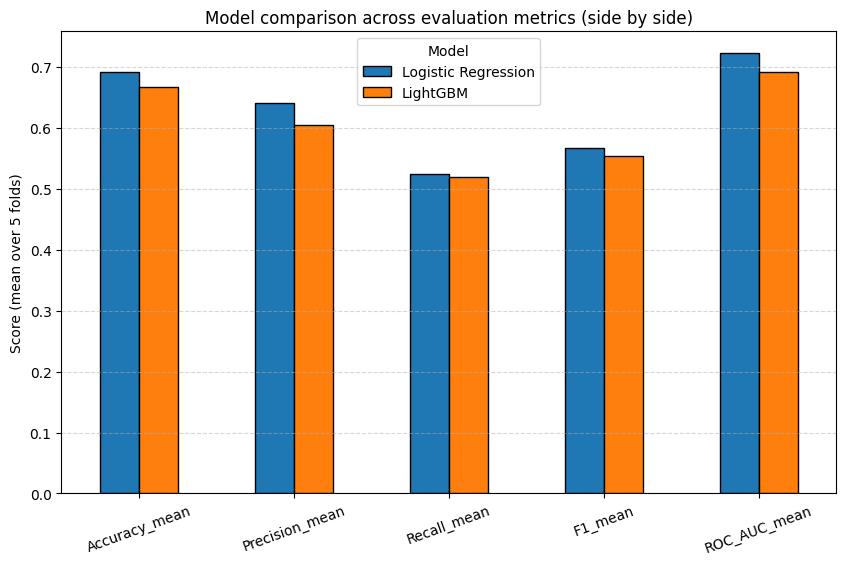

In [31]:
plot_metrics = [
    "Accuracy_mean",
    "Precision_mean",
    "Recall_mean",
    "F1_mean",
    "ROC_AUC_mean",
]

plot_df = comparison.set_index("Model")[plot_metrics].T 


ax = plot_df.plot.bar(rot=20, figsize=(10, 6), edgecolor="black")
ax.set_ylabel("Score (mean over 5 folds)")
ax.set_title("Model comparison across evaluation metrics (side by side)")
ax.legend(title="Model")
ax.grid(axis="y", linestyle="--", alpha=0.5)



### Modellvergleich 
- **Accuracy:** LR 0,669 ± 0,044 vs. LGBM 0,642 ± 0,054  
  - LR trifft insgesamt häufiger die richtige Entscheidung.
- **Precision:** LR 0,647 ± 0,095 vs. LGBM 0,580 ± 0,090  
  - Wenn das Modell „Top 10“ sagt, liegt LR öfter richtig (weniger False Positives).
- **Recall:** LR 0,560 ± 0,103 vs. LGBM 0,519 ± 0,210  
  - LR findet mehr echte Top-10-Fälle; LGBM ist hier sehr instabil (starke Schwankungen).
- **F1-Score:** LR 0,593 ± 0,082 vs. LGBM 0,535 ± 0,162  
  - LR hat den besseren Kompromiss aus Precision und Recall.
- **ROC-AUC:** LR 0,731 ± 0,061 vs. LGBM 0,675 ± 0,095  
  - LR trennt „Top 10“ vs. „nicht Top 10“ insgesamt besser (schwellenunabhängig).
- **PR-AUC:** LR 0,652 ± 0,093 vs. LGBM 0,603 ± 0,122  
  - LR ist besser beim Trade-off zwischen „möglichst viele Top-10 finden“ und „wenig Fehlalarme“; oft besonders relevant bei unausgeglichenen Klassen.

### Takeaway
- **Baseline (Logistische Regression) schlägt LightGBM** in deinem Setup klar: bessere Werte + stabilere Leistung.

In [32]:
# --- Fit LR pipeline on train split ---
pipeline_lr.fit(X_train, y_train)
print("LR pipeline fitted on train split.")

# --- Fit LGBM on train split ---
lgbm.fit(X_train, y_train)
print("LGBM fitted on train split.")


LR pipeline fitted on train split.
[LightGBM] [Info] Number of positive: 8819, number of negative: 11261
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000258 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 702
[LightGBM] [Info] Number of data points in the train set: 20080, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
LGBM fitted on train split.


## Ergebnisse 

- **Logistische Regression** ist in **allen Metriken besser** als **LightGBM** und wirkt **stabiler** (meist kleinere Std).
- **LightGBM** zeigt besonders beim **Recall** und **F1** eine **hohe Streuung**, d.h. die Leistung schwankt stark zwischen den Folds.

Aufgrund dieser Ergebnisse wurde die **logistische Regression**  
als **finales Modell ausgewählt** und anschließend auf dem **vollständigen Datensatz trainiert**.


In [33]:
pipeline_lr.fit(X_encoded, y)

print("Final model (Logistic Regression) trained on full dataset.")

Final model (Logistic Regression) trained on full dataset.


In [34]:
import joblib

joblib.dump(pipeline_lr, "../data/processed/final_model_logreg.joblib")

print("Final Logistic Regression model saved to data/processed/final_model_logreg.joblib")


Final Logistic Regression model saved to data/processed/final_model_logreg.joblib


Stärkste negative Koeffizienten (senken Top-10-Wahrscheinlichkeit):
num__constructor_strength              -0.452289
num__driver_recent_form                -0.168367
num__driver_experience                  0.085987
remainder__grid_bucket_mid_11_20        0.511896
remainder__grid_bucket_top10_4_10       1.272525
remainder__grid_bucket_front_row_1_3    1.530722
dtype: float64

Stärkste positive Koeffizienten (erhöhen Top-10-Wahrscheinlichkeit):
num__constructor_strength              -0.452289
num__driver_recent_form                -0.168367
num__driver_experience                  0.085987
remainder__grid_bucket_mid_11_20        0.511896
remainder__grid_bucket_top10_4_10       1.272525
remainder__grid_bucket_front_row_1_3    1.530722
dtype: float64


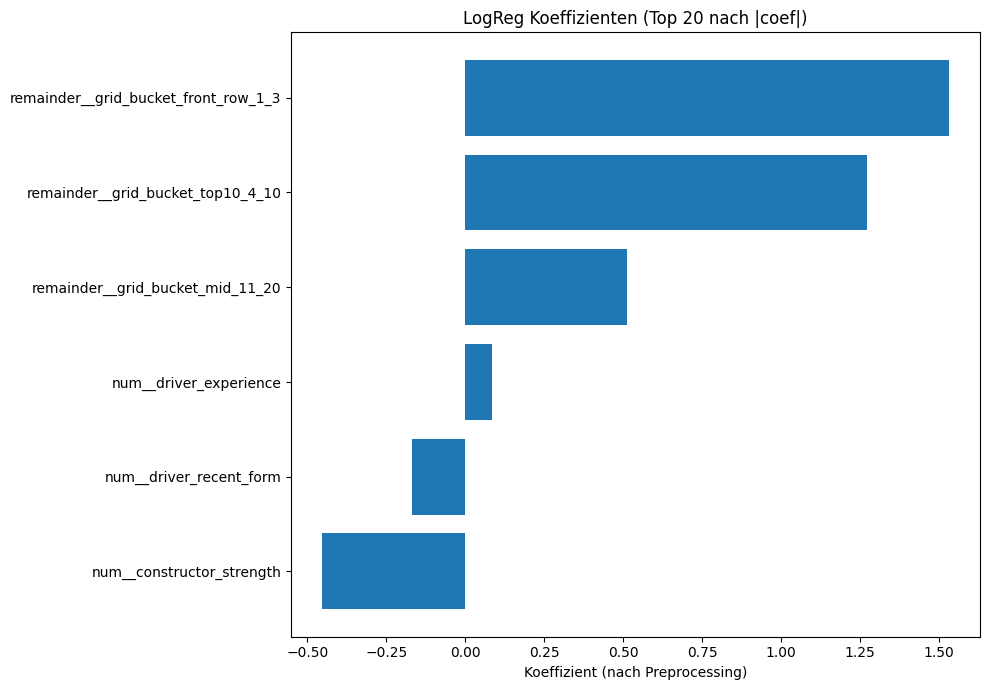

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Get correct feature names after the pipeline preprocessing step
pre = pipeline_lr.named_steps["preprocess"]
feat_names = pre.get_feature_names_out()

lr_model = pipeline_lr.named_steps["model"]
coef = lr_model.coef_[0]

coef_series = pd.Series(coef, index=feat_names).sort_values()

print("Stärkste negative Koeffizienten (senken Top-10-Wahrscheinlichkeit):")
print(coef_series.head(15))

print("\nStärkste positive Koeffizienten (erhöhen Top-10-Wahrscheinlichkeit):")
print(coef_series.tail(15))

# Plot top coefficients by absolute value (optional)
top_n = 20
top = coef_series.reindex(coef_series.abs().sort_values(ascending=False).head(top_n).index).sort_values()

plt.figure(figsize=(10, 7))
plt.barh(top.index, top.values)
plt.xlabel("Koeffizient (nach Preprocessing)")
plt.title(f"LogReg Koeffizienten (Top {top_n} nach |coef|)")
plt.tight_layout()
plt.show()


**Note**: driver_recent_form & constructor_strength negative --> je besser die Form, desto kleiner der Wert. Nach Standardisierung heißt ein negativer Koeffizient: niedrigerer Mittelwert (bessere Form) → höhere Top‑10‑Wahrscheinlichkeit.


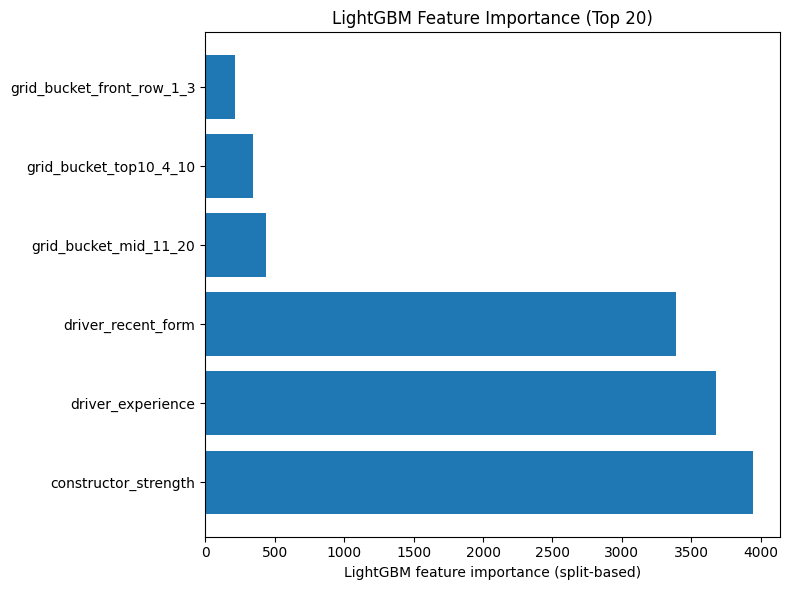

In [36]:
import matplotlib.pyplot as plt

# Gain-based importance is often more meaningful than split-count
importances = pd.Series(lgbm.feature_importances_, index=X_train.columns).sort_values(ascending=False)

top_n = 20
plt.figure(figsize=(8, 6))
plt.barh(importances.head(top_n).sort_values().index, importances.head(top_n).sort_values().values)
plt.gca().invert_yaxis()
plt.xlabel("LightGBM feature importance (split-based)")
plt.title(f"LightGBM Feature Importance (Top {top_n})")
plt.tight_layout()
plt.show()


## 🏁 Ergebnis des Modelltrainings

Das finale Modell lernt aus vor dem Rennen bekannten Merkmalen die Wahrscheinlichkeit einer Top-10-Platzierung.

- Validierung: Stratifizierte CV für eine robuste Gesamteinschätzung und TimeSeriesSplit für eine zeitlich korrekte Prognose ohne Zukunfts-Leck. 
- Holdout: Das letzte Rennen im Datensatz bleibt außen vor und dient als realitätsnaher Test.

Damit liegt eine belastbare Vorhersagebasis für Vor-dem-Rennen-Prognosen vor.

